# <span id='title' style='color: darkblue'>Predicting Employee Productivity Using Tree Models</span>

## <span id='TOC' style='color: blue'>Table of Contents</span>

* [Introduction](#Introduction)
* [Dataset Exploration](#DatasetExploration)
* [Dataset Cleaning](#DatasetCleaning)
* [Building the Tree](#BuildingTheTree)
* [Visualising and Evaluating the Tree](#VisualisingEvaluating)
* [Explaining the Tree](#ExplainingTheTree)
* [Using Random Forest](#RandomForest)
* [Conclusion](#Conclusion)

## <span id='Introduction' style='color: blue'>Introduction</span>

The aim of this project is to build a model to predict the productivity performance of working teams in garment factories.

The dataset ['Productivity Prediction of Garment Employees'](https://archive.ics.uci.edu/dataset/597/productivity+prediction+of+garment+employees) can be found by following the link to the UCI Machine Learning Repository.

The repository provides the following information about the dataset:

>*The Garment Industry is one of the key examples of the industrial globalization of this modern era.</br>It is a highly labour-intensive industry with lots of manual processes.</br>Satisfying the huge global demand for garment products is mostly dependent on the production and delivery performance of the employees in the garment manufacturing companies.</br>So, it is highly desirable among the decision makers in the garments industry to track, analyse and predict the productivity performance of the working teams in their factories.</br>This dataset can be used for regression purpose by predicting the productivity range (0-1) or for classification purpose by transforming the productivity range (0-1) into different classes.*

It also provides the following column information:

1. `date`: date in MM-DD-YYYY
1. `quarter`: a portion of the month — month was divided into four quarters
1. `department`: associated department with the instance
1. `day`: day of the week
1. `team`: associated team number with the instance
1. `targeted_productivity`: targeted productivity set by the authority for each team for each day
1. `smv`: standard minute value — the allocated time for a task
1. `wip`: work in progress — includes the number of unfinished items for products
1. `over_time`: represents the amount of overtime by each team in minutes
1. `incentive`: represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action
1. `idle_time`: the duration of time when the production was interrupted due to several reasons
1. `idle_men`: the number of workers who were idle due to production interruption
1. `no_of_style_change`: number of changes in the style of a particular product
1. `no_of_workers`: number of workers on each team
1. `actual_productivity`: the actual % of productivity that was delivered by the workers — it ranges from 0 to 1.


[Return to top](#title)

## <span id='DatasetExploration' style='color: blue'>Dataset Exploration</span>

*<span style='color: green'>Import the required libraries...</span>*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

*<span style='color: green'>Import the dataset into a DataFrame...</span>*

In [2]:
df = pd.read_csv('garments_worker_productivity.csv',
                 parse_dates=['date'],
                 date_format='%m/%d/%Y')

*<span style='color: green'>Inspect the dataset...</span>*

In [3]:
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,2015-01-01,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,2015-01-01,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,2015-01-01,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,2015-01-01,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,2015-01-01,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [4]:
df.shape

(1197, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1197 non-null   datetime64[ns]
 1   quarter                1197 non-null   object        
 2   department             1197 non-null   object        
 3   day                    1197 non-null   object        
 4   team                   1197 non-null   int64         
 5   targeted_productivity  1197 non-null   float64       
 6   smv                    1197 non-null   float64       
 7   wip                    691 non-null    float64       
 8   over_time              1197 non-null   int64         
 9   incentive              1197 non-null   int64         
 10  idle_time              1197 non-null   float64       
 11  idle_men               1197 non-null   int64         
 12  no_of_style_change     1197 non-null   int64         
 13  no_

In [6]:
categories = ['quarter', 'department', 'day', 'team']
for category in categories:
    print(df[category].value_counts())

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64
department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64
day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     199
Monday       199
Saturday     187
Name: count, dtype: int64
team
8     109
2     109
1     105
4     105
9     104
10    100
12     99
7      96
3      95
6      94
5      93
11     88
Name: count, dtype: int64


In [7]:
print(f'Earliest date: {df['date'].min():%d/%m/%Y}')
print(f'Latest date: {df['date'].max():%d/%m/%Y}')

Earliest date: 01/01/2015
Latest date: 11/03/2015


In [8]:
df.describe()

,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,2015-02-04 10:56:50.526315776,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
min,2015-01-01 00:00:00,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,2015-01-18 00:00:00,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,2015-02-03 00:00:00,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,2015-02-23 00:00:00,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,2015-03-11 00:00:00,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437
std,NaN,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488


There are a total of 1,197 rows in the DataFrame accross a total of 15 columns, including `actual_prodictivity` as the target column.

There are a number of potential issues to be dealt with prior to modelling:

* The records cover the `date` range 01/01/2015 to 11/03/2015.

* The `quarter` column actually contains 5 categories and is *not* quarters of a year.

* There is an issue with the category column, `department` that is likely a trailing space character.

* There are no records where `day` is Friday.

* There are a number of numerical columns with few values that may end up not being useful.

* `no_of_workers` has a data type of float64 and should be integers.

* There are values in `actual_productivity` that exceed the stated maximum for that column.

* The mean value of `targeted_productivity` is slightly below the mean of `actual_productivity` indicating that, notwithstanding the point about values outside the allowable range, productivity generally exceeds target.

[Return to top](#title)

## <span id='DatasetCleaning' style='color: blue'>Dataset Cleaning</span>

The information in the `date` column is covered in the category columns for `quarter` and `day` and can ultimately be removed. However, the 'Quarter5' values in `quarter` need to be investigated first.

In [9]:
df[df['quarter'] == 'Quarter5']['date'].value_counts()

date
2015-01-31    24
2015-01-29    20
Name: count, dtype: int64

The dates associated with 'Quarter5' are all at the end of the month so will be reallocated to a `quarter` value of 'Quarter4'. As the values in this column are not ordered, dummy columns will then be created for each category.

In [10]:
df.loc[df['quarter'] == 'Quarter5', 'quarter'] = 'Quarter4'
df['quarter'].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: count, dtype: int64

In [11]:
df.drop('date', axis=1, inplace=True)

For naming consistency, before creating the dummy columns for `quarter`, convert the values to lower case.

In [12]:
df['quarter'] = df['quarter'].str.lower()
df['quarter'].unique()

array(['quarter1', 'quarter2', 'quarter3', 'quarter4'], dtype=object)

In [13]:
df = pd.concat([df, pd.get_dummies(df['quarter'], prefix=None, dtype=int)], axis=1).drop('quarter', axis=1)
df.head()

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,quarter1,quarter2,quarter3,quarter4
0,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,1,0,0,0
1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,1,0,0,0
2,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1,0,0,0
3,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,1,0,0,0
4,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,1,0,0,0


The issue with `department` will be fixed by checking for any trailing spaces in the values and replacing with the correct values.

In [14]:
df['department'].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [15]:
df.loc[df['department'] == 'finishing ', 'department'] = 'finishing'
df['department'].unique()

array(['sweing', 'finishing'], dtype=object)

For modelling purposes, a new column from `department` will be created where 1 will represent the 'finishing' department and 0 will represent 'sweing' ('sewing'?).

In [16]:
df['finishing_department'] = df['department'].apply(lambda x: 1 if x == 'finishing' else 0)
df.drop('department', axis=1, inplace=True)

To complete processing of the categorical columns, dummies will be created for `day` (after converting to lower case) and `team`.

In [17]:
df['day'] = df['day'].str.lower()
df = pd.concat([df, pd.get_dummies(df['day'], prefix=None, dtype=int)], axis=1).drop('day', axis=1)
df = pd.concat([df, pd.get_dummies(df['team'], prefix='team')], axis=1).drop('team', axis=1)
df.head()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,...,team_3,team_4,team_5,team_6,team_7,team_8,team_9,team_10,team_11,team_12
0,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,...,False,False,False,False,False,True,False,False,False,False
1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,...,False,False,False,False,False,False,False,False,False,False
2,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,...,False,False,False,False,False,False,False,False,True,False
3,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,...,False,False,False,False,False,False,False,False,False,True
4,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,...,False,False,False,True,False,False,False,False,False,False


The columns `idle_time` and `idle_men` have very few values so will be investigated to assess their usefulness in the model.

In [18]:
df[df['idle_time'] > 0].shape[0]

18

In [19]:
df[df['idle_men'] > 0].shape[0]

18

In [20]:
df[(df['idle_time'] > 0) & (df['idle_men'] > 0)].shape[0]

18

`idle_time` and `idle_men` are related and only have values when they both have values and as there are only 18 non zero observations, these columns will be deleted.

In [21]:
df.drop(['idle_time', 'idle_men'], axis=1, inplace=True)

The column `wip` has a lot of missing values and as it is unknown whether they are missing or should be zero, this column shall also be deleted.

In [22]:
df.drop('wip', axis=1, inplace=True)

Investigate how much information is in column `no_of_style_change`.

In [23]:
print(df[df['no_of_style_change'] != 0].shape[0])
print(df['no_of_style_change'].value_counts())

147
no_of_style_change
0    1050
1     114
2      33
Name: count, dtype: int64


As there are relatively few values, this column shall be deleted.

In [24]:
df.drop('no_of_style_change', axis=1, inplace=True)

Currently, `no_of_workers` is stored as a float and should be converted to an integer. Also, for consistency, `actual_productivity` should be rounded to two decimal places to align with `targeted_productivity`.

In [25]:
df['no_of_workers'] = df['no_of_workers'].astype('int')
df['actual_productivity'] = df['actual_productivity'].round(2)

As the model's purpose is to predict whether a team will be productive or not, a new column `productive` will be created which will be based on whether `actual_productivity` is greater than or equal to `targeted_productivity`.

In [26]:
df['productive'] = df['actual_productivity'] >= df['targeted_productivity']

Following this processing, inspect the remaining column names and reorder the DataFrame columns for ease of reading if necessary.

In [27]:
df.columns

Index(['targeted_productivity', 'smv', 'over_time', 'incentive',
       'no_of_workers', 'actual_productivity', 'quarter1', 'quarter2',
       'quarter3', 'quarter4', 'finishing_department', 'monday', 'saturday',
       'sunday', 'thursday', 'tuesday', 'wednesday', 'team_1', 'team_2',
       'team_3', 'team_4', 'team_5', 'team_6', 'team_7', 'team_8', 'team_9',
       'team_10', 'team_11', 'team_12', 'productive'],
      dtype='object')

In [28]:
df = df[['quarter1', 'quarter2', 'quarter3', 'quarter4',
         'monday', 'tuesday', 'wednesday', 'thursday', 'saturday', 'sunday',
         'team_1', 'team_2', 'team_3', 'team_4', 'team_5', 'team_6',
         'team_7', 'team_8', 'team_9', 'team_10', 'team_11', 'team_12',
         'finishing_department', 'smv', 'over_time', 'incentive', 'no_of_workers',
         'targeted_productivity', 'actual_productivity', 'productive']]
df.head()

,quarter1,quarter2,quarter3,quarter4,monday,tuesday,wednesday,thursday,saturday,sunday,...,team_11,team_12,finishing_department,smv,over_time,incentive,no_of_workers,targeted_productivity,actual_productivity,productive
0,1,0,0,0,0,0,0,1,0,0,...,False,False,0,26.16,7080,98,59,0.80,0.94,True
1,1,0,0,0,0,0,0,1,0,0,...,False,False,1,3.94,960,0,8,0.75,0.89,True
2,1,0,0,0,0,0,0,1,0,0,...,True,False,0,11.41,3660,50,30,0.80,0.80,True
3,1,0,0,0,0,0,0,1,0,0,...,False,True,0,11.41,3660,50,30,0.80,0.80,True
4,1,0,0,0,0,0,0,1,0,0,...,False,False,0,25.90,1920,50,56,0.80,0.80,True


[Return to top](#title)

## <span id='BuildingTheTree' style='color: blue'>Building the Tree</span>

*<span style='color: green'>Split DataFrame into features and target DataFrames...</span>*

In [29]:
X = df.drop(['actual_productivity', 'productive'], axis=1)
y = df['productive']

*<span style='color: green'>Split the data into training and test datasets...</span>*

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=6)

*<span style='color: green'>Instantiate and fit the Decision Tree Classifier model...</span>*

In [31]:
model = DecisionTreeClassifier(max_depth=3, random_state=6)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


*<span style='color: green'>Use the model to make predictions on the test data...</span>*

In [32]:
y_pred = model.predict(X_test)

*<span style='color: green'>Get the accuracy score of the model on the test predictions...</span>*

In [33]:
test_accuracy = accuracy_score(y_test, y_pred)
print(f'The accuracy score of the model on the test data predictions is {test_accuracy:.3f}')

The accuracy score of the model on the test data predictions is 0.825


[Return to top](#title)

## <span id='VisualisingEvaluating' style='color: blue'>Visualising and Evaluating the Tree</span>

*<span style='color: green'>Plot the model using `plot_tree`...</span>*

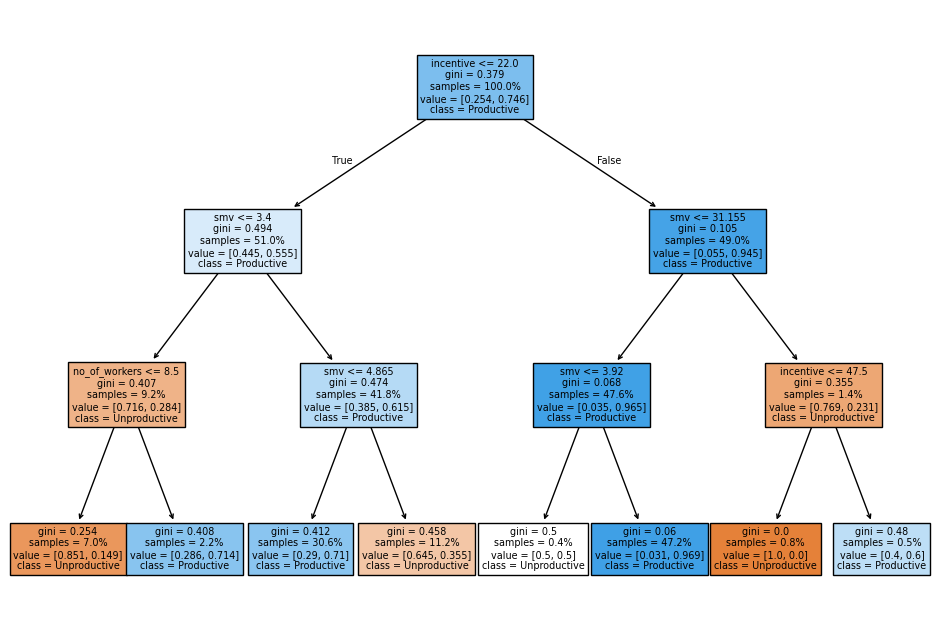

In [34]:
plt.figure(figsize=(12, 8))
_ = plot_tree(model,
              feature_names=X.columns,
              class_names=['Unproductive', 'Productive'],
              filled=True,
              proportion=True)

The plot shows that `smv` (the allocated time for a task) and `incentive` are the most important features for predicting productivity. `no_of_workers` also appears in the decision tree.

In [35]:
confusion_matrix(y_test, y_pred)

array([[ 32,  27],
       [ 15, 166]])

The `confusion_matrix()` shows that there were 32 true negatives and 166 true positives when comparing the predictions with the test data.

In [36]:
print(f'Precision: {precision_score(y_test, y_pred):.3f}')

Precision: 0.860


There is a precision score of 0.86, which is the ratio of true positives against the sum of the true positives and false positives:

$$\text{Precision} = \frac{166}{(166 + 27)}$$

In [37]:
print(f'Recall: {recall_score(y_test, y_pred): .3f}')

Recall:  0.917


There is a recall score of 0.917 which is the ratio of true positives against the sum of true positives and false negatives:

$$\text{Recall} = \frac{166}{166+15}$$

In [38]:
print(f'F1 Score: {f1_score(y_test, y_pred):.3f}')

F1 Score: 0.888


There is an F1 score of 0.888 which is calculated by:

$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

These metrics, along with the accuracy score of 0.825 are all very good for a first attempt at a model for predictive whether a team will be productive or not.

[Return to top](#title)

## <span id='ExplainingTheTree' style='color: blue'>Explaining the Tree</span>

As stated, the features `smv`, `incentive` and `no_of_workers` are the ones that the model uses to make a prediction.

For each step, the model makes a decision on the value of the feature in question and branches to the left (true condition) or right (false) to the next level in the tree.

So, starting with the value of `incentive`, the model will brach left if it is less than or equal to 22.0 and right otherwise. These decision continue down the levels of the tree until a 'leaf' is reached. That is, a level with no further decisions to be made.

For example, say there was a new observation with the following values (note that values of any other features are not relevant):

* `incentive`: 63
* `smv`: 28.08
* `no_of_workers`: 58

The model would first test whether the `incentive` is less than or equal to 22.0. This is false, so the tree would branch to the right. It then tests whether `smv` is less than or equal to 31.155 which is true. It therefore branches to the left this time to again test against whether `smv` is less than or equal to 3.92. As this is not true, it goes to the right and reaches a 'leaf' node that gives the prediction, 'Productive'.

Another example, would be a record with the following values:

* `incentive`: 0
* `smv`: 4.15
* `no_of_workers`: 12

This time, `incentive` is less than 22.0 so it goes to the left to test whether `smv` is less than or equal to 3.4. This is false so it goes to the right to the next level that tests whether it is less than or equal to 4.865. This is true so the next level on the left is a 'leaf' that gives a predicted outcome of 'Productive'.

Note that in its current form, an observation to make a prediction on has to have the same structure as the features dataset. That is, even though the model only tests the specified three features, there still has to be values for the others.

[Return to top](#title)

## <span id='RandomForest' style='color: blue'>Using Random Forest</span>

To try to verify how good the model is or not, another model will be created using the `sklearn` `RandomForestClassifier` from `sklearn.ensemble`. The results will then be compared to the original model to verify how good it was.

In [39]:
rf_model = RandomForestClassifier(oob_score=True, random_state=6)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f'Accuracy Score of Random Forest Classifier: {accuracy_score(y_test, y_pred):.3f}')
print(f"'Out of Bag' Score of Random Forest Classifier: {rf_model.oob_score_:.3f}")

Accuracy Score of Random Forest Classifier: 0.825
'Out of Bag' Score of Random Forest Classifier: 0.837


These results are very similar to the original model. In fact, the accuracy scores are exactly the same. This means that there is confidence in the original model's performance.

[Return to top](#title)

## <span id='Conclusion' style='color: blue'>Conclusion</span>

This project took a dataset relating to garment manufacturing productivity and built a predictive model with Scikit Learn's Decision Tree Classifier.

The data was analysed, cleaned and engineered to make it optimal for the model to work with.

The model was good at predicting whether a production team would be productive or not, that is, having a measure of productivey that is greater than or equal to the target productivity with an *accuracy* score of **0.825**, backed up by very good *precision, recall* and *f1* scores.

This score was tested for robustness by implementing a Random Forest Classifier model which backed the result by also producing an *accuracy* score of 0.825.

This particular model resulted in the features **`incentive`** and **`smv`** (allocated time per task) as being the most important with `no_of_workers` relevant is some circumstances.